In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectPercentile, chi2, f_classif
from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    make_scorer,
    roc_curve,
    roc_auc_score,
)
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
import os
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier

In [ ]:
loguniform(1e-3, 3e-1)

In [10]:
# =====================
# 1. Load data
# =====================
year = 2
path = f"RCC_{year}yr_mortality_dataset.csv"  # adjust if needed
df = pd.read_csv(path)

# Get the name of the last column
last_column_name = df.columns[-1]


X = df.drop(columns=[last_column_name])
y = df[last_column_name]

# =====================
# 2. Feature types
# =====================
numeric_features = [
    "Total number of in situ/malignant tumors for patient",
    "Total number of benign/borderline tumors for patient",
]

categorical_features = [c for c in X.columns if c not in numeric_features]


In [18]:
X.columns

Index(['Age recode with <1 year olds and 90+',
       'Race recode (White, Black, Other)', 'Sex',
       'ICCC site recode 3rd edition/IARC 2017', 'Laterality',
       'ICD-O-3 Hist/behav', 'Site recode ICD-O-3/WHO 2008 (for SIRs)',
       'Site recode - rare tumors',
       'Combined Summary Stage with Expanded Regional Codes (2004+)',
       'RX Summ--Surg Oth Reg/Dis (2003+)', 'RX Summ--Surg/Rad Seq',
       'Reason no cancer-directed surgery', 'Radiation recode',
       'Chemotherapy recode (yes, no/unk)',
       'Time from diagnosis to treatment in days recode',
       'Invasion Beyond Capsule Recode (2010+)',
       'Ipsilateral Adrenal Gland Involvement Recode (2010+)',
       'Major Vein Involvement Recode (2010+)',
       'Sarcomatoid Features Recode (2010+)',
       'Tumor Size Over Time Recode (1988+)',
       'SEER Combined Mets at DX-bone (2010+)',
       'SEER Combined Mets at DX-brain (2010+)',
       'SEER Combined Mets at DX-liver (2010+)',
       'SEER Combined Mets a

In [7]:
# =========================================================
# 2. preprocessing
# =========================================================
# Numeric: scale
numeric_filter = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

# Categorical: one-hot
categorical_filter = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor_filter = ColumnTransformer(
    transformers=[
        ("num", numeric_filter, numeric_features),
        ("cat", categorical_filter, categorical_features),
    ]
)

In [ ]:
# =========================================================
# 1. XGBoost classifier for BINARY task
# =========================================================
xgb_clf = XGBClassifier(
    objective="binary:logistic",   # binary objective
    tree_method="hist",
    eval_metric="logloss",         # binary logloss
    booster="gbtree",
    n_jobs=1,                      # single-thread; CV parallelizes over folds
    random_state=42,
)

# Full FILTER-ONLY pipeline
pipe_filter = Pipeline(
    steps=[
        ("preprocess", preprocessor_filter),
        ("xgb", xgb_clf),
    ]
)

# =========================================================
# 2. Hyperparameter space (XGB + filter strength)
# =========================================================
param_distributions_filter = {
    "xgb__n_estimators":      randint(200, 1200),
    "xgb__max_depth":         randint(3, 9),
    "xgb__learning_rate":     loguniform(1e-3, 3e-1),
    "xgb__subsample":         uniform(0.6, 0.4),    # 0.6 – 1.0
    "xgb__colsample_bytree":  uniform(0.6, 0.4),    # 0.6 – 1.0
    "xgb__min_child_weight":  loguniform(1e-1, 1e2),
    "xgb__gamma":             loguniform(1e-3, 10),
    "xgb__reg_alpha":         loguniform(1e-6, 1.0),
    "xgb__reg_lambda":        loguniform(1e-3, 10),
}

# MCC scorer for binary classification
mcc_scorer = make_scorer(matthews_corrcoef)

In [ ]:
# =========================================================
# 3. Nested CV configuration
# =========================================================
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

N_ITER_SEARCH = 50

# Artifact directory
output_dir = f"xgb_binary_artifacts_year{year}"
os.makedirs(output_dir, exist_ok=True)

# Storage for results
fold_metrics = []          # list of dict per outer fold
roc_curves = []            # list of (fpr, tpr, auc, fold)
feat_importances_folds = []  # list of Series (permutation importance per fold)

# =========================================================
# 4. Outer loop
# =========================================================
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
    print(f"\n=== Outer fold {fold}/10  (binary XGB) ===")

    X_train_outer, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ----- inner CV hyperparameter search -----
    search = RandomizedSearchCV(
        estimator=pipe_filter,
        param_distributions=param_distributions_filter,
        n_iter=N_ITER_SEARCH,
        scoring=mcc_scorer,   # MCC for tuning
        n_jobs=-1,
        cv=inner_cv,
        refit=True,
        verbose=1,
        random_state=42,
    )

    search.fit(X_train_outer, y_train_outer)

    best_model = search.best_estimator_
    best_idx = search.best_index_
    best_mean_inner = search.cv_results_["mean_test_score"][best_idx]
    best_std_inner = search.cv_results_["std_test_score"][best_idx]

    print("Best params:", search.best_params_)
    print(
        f"Best inner-CV MCC (mean ± std) = "
        f"{best_mean_inner:.4f} ± {best_std_inner:.4f}"
    )

    # ----- evaluate on outer test set -----
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    mcc = matthews_corrcoef(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred,
        average="binary",
        zero_division=0
    )
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)

    print(
        f"Outer fold {fold}: MCC={mcc:.4f}, BalAcc={bal_acc:.4f}, "
        f"Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc_val:.4f}"
    )

    # Save metrics dict
    fold_metrics.append({
        "fold": fold,
        "MCC": mcc,
        "BalancedAccuracy": bal_acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc_val,
        "best_inner_MCC_mean": best_mean_inner,
        "best_inner_MCC_std": best_std_inner,
        **search.best_params_,
    })

    # Store ROC for overlay
    roc_curves.append((fpr, tpr, auc_val, fold))

    # ----- save ROC curve plot for this fold -----
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"Fold {fold} (AUC = {auc_val:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="No skill")
    plt.xlabel("False positive rate (1 - specificity)")
    plt.ylabel("True positive rate (sensitivity)")
    plt.title(f"ROC curve – Fold {fold}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"roc_fold{fold}.png"), dpi=300)
    plt.close()

    # ----- permutation feature importance on outer test -----
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        scoring=mcc_scorer,      # importance wrt MCC
        n_repeats=10,
        random_state=42,
        n_jobs=-1,
    )

    fold_imp = pd.Series(
        perm.importances_mean,
        index=X.columns,         # original feature names (pipeline handles transforms)
        name=f"fold_{fold}",
    )

    # Save per-fold importance CSV
    fold_imp.sort_values(ascending=False).to_csv(
        os.path.join(output_dir, f"feature_importance_fold{fold}.csv")
    )

    # Optional per-fold barplot (top 20)
    top_k = 20
    top_imp = fold_imp.sort_values(ascending=False).head(top_k)
    plt.figure(figsize=(8, 6))
    top_imp.sort_values().plot(kind="barh")
    plt.xlabel("Mean permutation importance (ΔMCC)")
    plt.title(f"XGB permutation importance – Fold {fold}")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"feature_importance_fold{fold}.png"), dpi=300)
    plt.close()

    feat_importances_folds.append(fold_imp)



=== Outer fold 1/10  (binary XGB) ===
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'xgb__colsample_bytree': np.float64(0.7186040574591194), 'xgb__gamma': np.float64(0.04776650059868054), 'xgb__learning_rate': np.float64(0.004311770785142483), 'xgb__max_depth': 7, 'xgb__min_child_weight': np.float64(0.1757043611370351), 'xgb__n_estimators': 1102, 'xgb__reg_alpha': np.float64(0.0010211693428871288), 'xgb__reg_lambda': np.float64(1.5602015889668863), 'xgb__subsample': np.float64(0.8599855723111061)}
Best inner-CV MCC (mean ± std) = 0.6220 ± 0.0165
Outer fold 1: MCC=0.5979, BalAcc=0.7846, Prec=0.7394, Rec=0.6431, F1=0.6879, AUC=0.8862

=== Outer fold 2/10  (binary XGB) ===
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'xgb__colsample_bytree': np.float64(0.7186040574591194), 'xgb__gamma': np.float64(0.04776650059868054), 'xgb__learning_rate': np.float64(0.004311770785142483), 'xgb__max_depth': 7, 'xgb__min_child_weight': np.flo

In [ ]:
# =========================================================
# 5. Save per-fold metrics + summary
# =========================================================
metrics_df = pd.DataFrame(fold_metrics)
metrics_path = os.path.join(output_dir, "xgb_binary_cv_folds_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved per-fold metrics to:", metrics_path)

# Summary mean ± std over folds (outer performance)
summary_df = pd.DataFrame({
    "metric": ["MCC", "BalancedAccuracy", "Precision", "Recall", "F1", "AUC"],
    "mean": [
        metrics_df["MCC"].mean(),
        metrics_df["BalancedAccuracy"].mean(),
        metrics_df["Precision"].mean(),
        metrics_df["Recall"].mean(),
        metrics_df["F1"].mean(),
        metrics_df["AUC"].mean(),
    ],
    "std": [
        metrics_df["MCC"].std(ddof=1),
        metrics_df["BalancedAccuracy"].std(ddof=1),
        metrics_df["Precision"].std(ddof=1),
        metrics_df["Recall"].std(ddof=1),
        metrics_df["F1"].std(ddof=1),
        metrics_df["AUC"].std(ddof=1),
    ],
})
summary_path = os.path.join(output_dir, "xgb_binary_cv_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved CV summary to:", summary_path)
print("\n===nested CV summary (binary) ===")
print(summary_df)

Saved per-fold metrics to: xgb_binary_artifacts_year2\xgb_binary_cv_folds_metrics.csv
Saved CV summary to: xgb_binary_artifacts_year2\xgb_binary_cv_summary.csv

===nested CV summary (binary) ===
             metric      mean       std
0               MCC  0.616961  0.028979
1  BalancedAccuracy  0.792041  0.013246
2         Precision  0.760527  0.026747
3            Recall  0.651098  0.019748
4                F1  0.701515  0.021976
5               AUC  0.894147  0.013369


In [ ]:
# =========================================================
# 6. Boxplots for metrics across outer folds
# =========================================================
metric_cols = ["MCC", "BalancedAccuracy", "Precision", "Recall", "F1", "AUC"]
metrics_only = metrics_df[metric_cols]

# one figure containing all metrics
plt.figure(figsize=(8, 5))
metrics_only.boxplot()
plt.title("XGB (binary): metrics across outer folds")
plt.ylabel("Score")
plt.ylim(0.0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "xgb_metrics_boxplot_all.png"), dpi=300)
plt.close()

# separate boxplots (with means)
for col in metric_cols:
    plt.figure(figsize=(4, 5))
    plt.boxplot(
        metrics_only[col].values,
        widths=0.5,
        showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "black", "markersize": 6},
    )
    plt.xticks([1], [col])
    plt.ylabel("Score")
    plt.ylim(0.0, 1.0)
    plt.title(f"XGB (binary): {col} across outer folds")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"xgb_boxplot_{col}.png"), dpi=300)
    plt.close()


In [ ]:
# =========================================================
# 7. Mean permutation feature importance over folds
# =========================================================
# Concatenate Series into DataFrame: rows=features, cols=folds
feat_imp_df = pd.concat(feat_importances_folds, axis=1)
mean_imp = feat_imp_df.mean(axis=1).sort_values(ascending=False)
mean_imp_path = os.path.join(output_dir, "feature_importance_mean_over_folds.csv")
mean_imp.to_csv(mean_imp_path, header=["mean_importance"])
print("Saved mean feature importance to:", mean_imp_path)

# Barplot for mean importance (top 20)
top_k = 20
top_mean_imp = mean_imp.head(top_k)
plt.figure(figsize=(8, 6))
top_mean_imp.sort_values().plot(kind="barh")
plt.xlabel("Mean permutation importance (ΔMCC) over folds")
plt.title("XGB permutation importance – mean over outer folds")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_importance_mean_over_folds.png"), dpi=300)
plt.close()

# =========================================================
# 8. Overlay ROC curves across folds
# =========================================================
plt.figure(figsize=(6, 5))
auc_vals = []
for fpr, tpr, auc_val, fold in roc_curves:
    auc_vals.append(auc_val)
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold} (AUC={auc_val:.3f})")

mean_auc = np.mean(auc_vals)
plt.plot([0, 1], [0, 1], "k--", label="No skill")
plt.xlabel("False positive rate (1 - specificity)")
plt.ylabel("True positive rate (sensitivity)")
plt.title(f"ROC curves – all outer folds (mean AUC = {mean_auc:.3f})")
plt.legend(loc="lower right", fontsize="small", ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
allroc_path = os.path.join(output_dir, "roc_all_folds.png")
plt.savefig(allroc_path, dpi=300)
plt.close()

print(f"Mean AUC over folds: {mean_auc:.4f}")
print("Saved overlay ROC plot to:", allroc_path)

Saved mean feature importance to: xgb_binary_artifacts_year2\feature_importance_mean_over_folds.csv
Mean AUC over folds: 0.8941
Saved overlay ROC plot to: xgb_binary_artifacts_year2\roc_all_folds.png


In [12]:
import os
import pandas as pd
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# -------------------------------------------------
# 1. Load best params from CV artifacts
# -------------------------------------------------
year = 2
# output_dir = f"xgb_binary_artifacts_year{year}"   # adjust if different
metrics_path = f"xgb_binary_cv_folds_metrics_year{year}.csv"

metrics_df = pd.read_csv(metrics_path)

# choose outer fold with highest MCC (you can change to AUC if you prefer)
best_fold_idx = metrics_df["MCC"].idxmax()
best_row = metrics_df.loc[best_fold_idx]

# extract columns starting with "xgb__" and strip prefix
best_xgb_params = {
    col.replace("xgb__", ""): best_row[col]
    for col in metrics_df.columns
    if col.startswith("xgb__")
}

print("Best XGB params from CV:")
for k, v in best_xgb_params.items():
    print(f"  {k}: {v}")
int_params = ["n_estimators", "max_depth"]  # add more if needed

for p in int_params:
    if p in best_xgb_params and not pd.isna(best_xgb_params[p]):
        best_xgb_params[p] = int(best_xgb_params[p])

print(best_xgb_params, {k: type(v) for k, v in best_xgb_params.items()})
# -------------------------------------------------
# 2. Build final XGB model with these params
# -------------------------------------------------
xgb_final = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    eval_metric="logloss",
    booster="gbtree",
    n_jobs=-1,          # now you can use all cores for final fit
    random_state=42,
    **best_xgb_params,
)

pipe_final = Pipeline(
    steps=[
        ("preprocess", preprocessor_filter),  # your ColumnTransformer
        ("xgb", xgb_final),
    ]
)

# -------------------------------------------------
# 3. Fit on all available data
# -------------------------------------------------
pipe_final.fit(X, y)
print("Final XGB pipeline fitted on full data.")

Best XGB params from CV:
  colsample_bytree: 0.7232243167409557
  gamma: 0.1479656554258492
  learning_rate: 0.0182135316363936
  max_depth: 8.0
  min_child_weight: 0.6246073681318088
  n_estimators: 949.0
  reg_alpha: 0.0034611871713471
  reg_lambda: 8.233252469730273
  subsample: 0.794696861183782
{'colsample_bytree': np.float64(0.7232243167409557), 'gamma': np.float64(0.1479656554258492), 'learning_rate': np.float64(0.0182135316363936), 'max_depth': 8, 'min_child_weight': np.float64(0.6246073681318088), 'n_estimators': 949, 'reg_alpha': np.float64(0.0034611871713471), 'reg_lambda': np.float64(8.233252469730273), 'subsample': np.float64(0.794696861183782)} {'colsample_bytree': <class 'numpy.float64'>, 'gamma': <class 'numpy.float64'>, 'learning_rate': <class 'numpy.float64'>, 'max_depth': <class 'int'>, 'min_child_weight': <class 'numpy.float64'>, 'n_estimators': <class 'int'>, 'reg_alpha': <class 'numpy.float64'>, 'reg_lambda': <class 'numpy.float64'>, 'subsample': <class 'numpy.flo

Saved SHAP importance to: xgb_shap_importance_year2.csv


/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipython-input-540065153.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


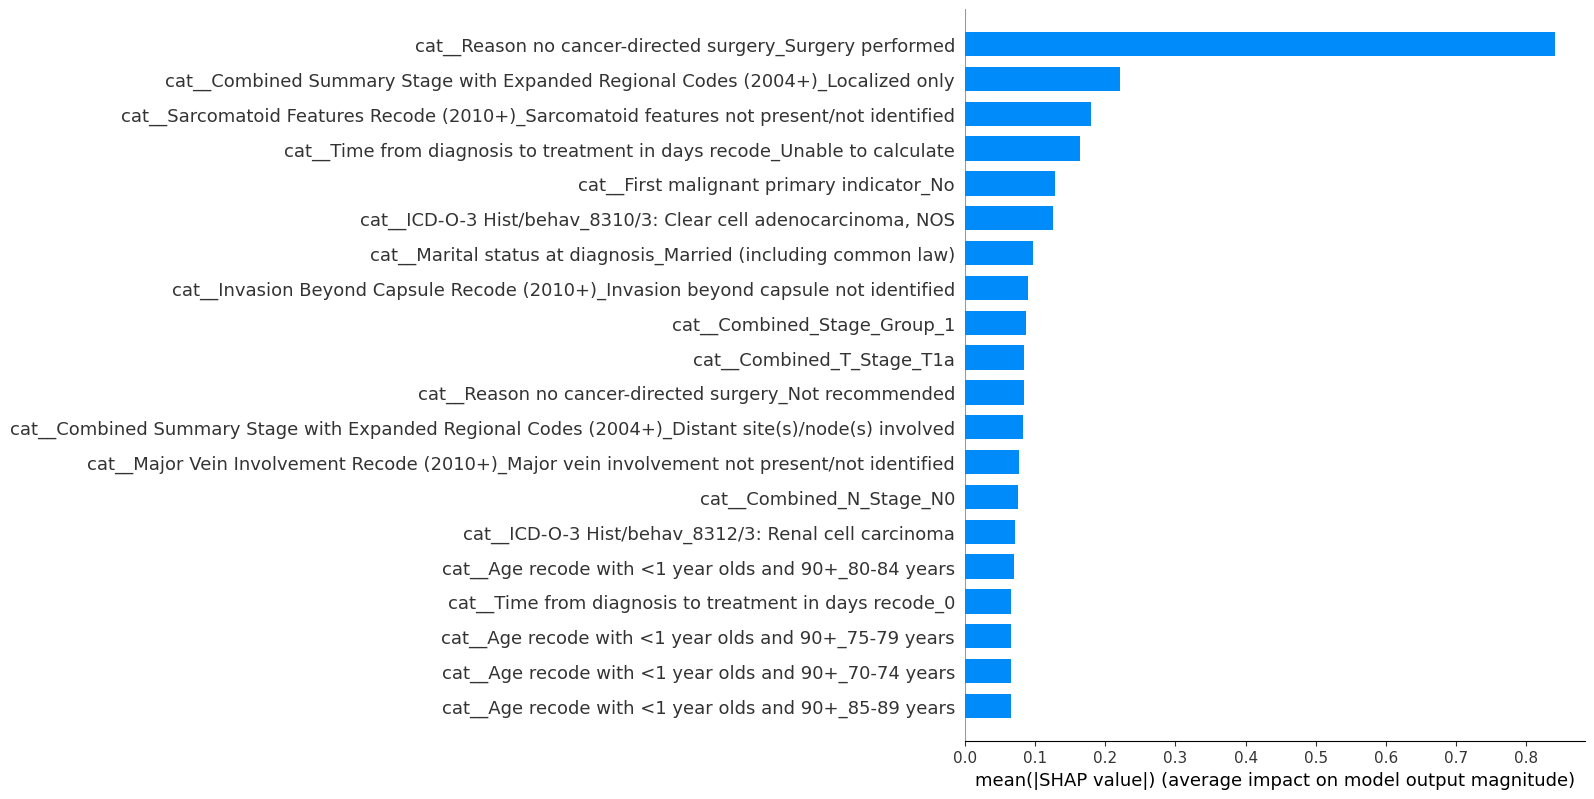

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipython-input-540065153.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


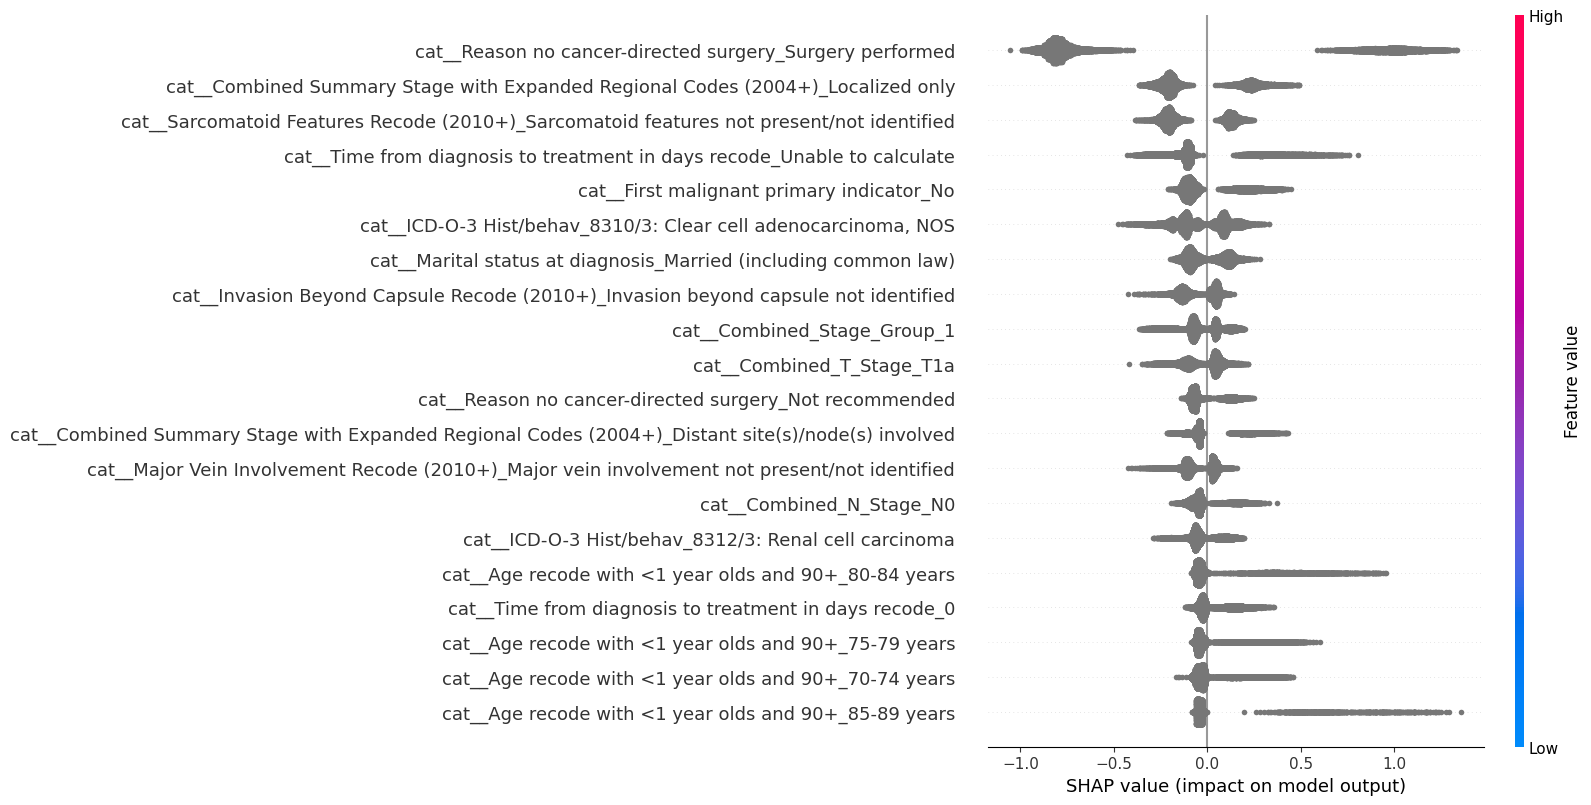

In [ ]:
import shap
# =========================================================
# 10. SHAP computation on encoded data
# =========================================================

# Subsample for speed (you can increase/decrease n_bg)
# n_bg = min(2000, X.shape[0])
X_bg = X

preproc = pipe_final.named_steps["preprocess"]
xgb_step = pipe_final.named_steps["xgb"]

X_bg_proc = preproc.transform(X_bg)

# encoded feature names
try:
    feature_names_enc = preproc.get_feature_names_out()
except AttributeError:
    # fallback: generic names if get_feature_names_out is not available
    feature_names_enc = [f"feat_{i}" for i in range(X_bg_proc.shape[1])]

# TreeExplainer for XGB
explainer = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_bg_proc)

# Handle list output for binary classification if necessary
if isinstance(shap_values, list):
    shap_vals_2d = shap_values[1]
else:
    shap_vals_2d = shap_values

# =========================================================
# FIX: Convert Sparse Matrix to Dense for Plotting
# =========================================================
# Check if X_bg_proc is sparse (Scipy CSR matrix) and convert to dense numpy array
if hasattr(X_bg_proc, "toarray"):
    X_bg_proc_dense = X_bg_proc.toarray()
else:
    X_bg_proc_dense = X_bg_proc

# Create a Pandas DataFrame to keep values and names together
# This ensures SHAP sees the actual values (0, 1, etc.) for coloring
X_bg_proc_df = pd.DataFrame(X_bg_proc_dense, columns=feature_names_enc)

# =========================================================
# 11. Save SHAP-based feature importance (mean |SHAP|)
# =========================================================
mean_abs = np.abs(shap_vals_2d).mean(axis=0)
imp_df = pd.DataFrame(
    {"feature": feature_names_enc, "mean_abs_shap": mean_abs}
).sort_values("mean_abs_shap", ascending=False)

imp_path = f"xgb_shap_importance_year{year}.csv"
imp_df.to_csv(imp_path, index=False)
print("Saved SHAP importance to:", imp_path)

# =========================================================
# 12. SHAP summary plots (bar + beeswarm)
# =========================================================

# bar plot
plt.figure()
shap.summary_plot(
    shap_vals_2d,
    X_bg_proc,
    feature_names=feature_names_enc,
    plot_type="bar",
    show=False,
)
plt.tight_layout()
plt.show()
# plt.savefig(os.path.join(output_dir, "xgb_shap_summary_bar.png"), dpi=300)
# plt.close()

# beeswarm plot
plt.figure()
shap.summary_plot(
    shap_vals_2d,
    X_bg_proc,
    feature_names=feature_names_enc,
    show=False,
)
plt.tight_layout()
plt.show()
# plt.savefig(os.path.join(output_dir, "xgb_shap_beeswarm.png"), dpi=300)
# plt.close()

# print("Saved SHAP bar and beeswarm plots to:", output_dir)

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipython-input-3890632981.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


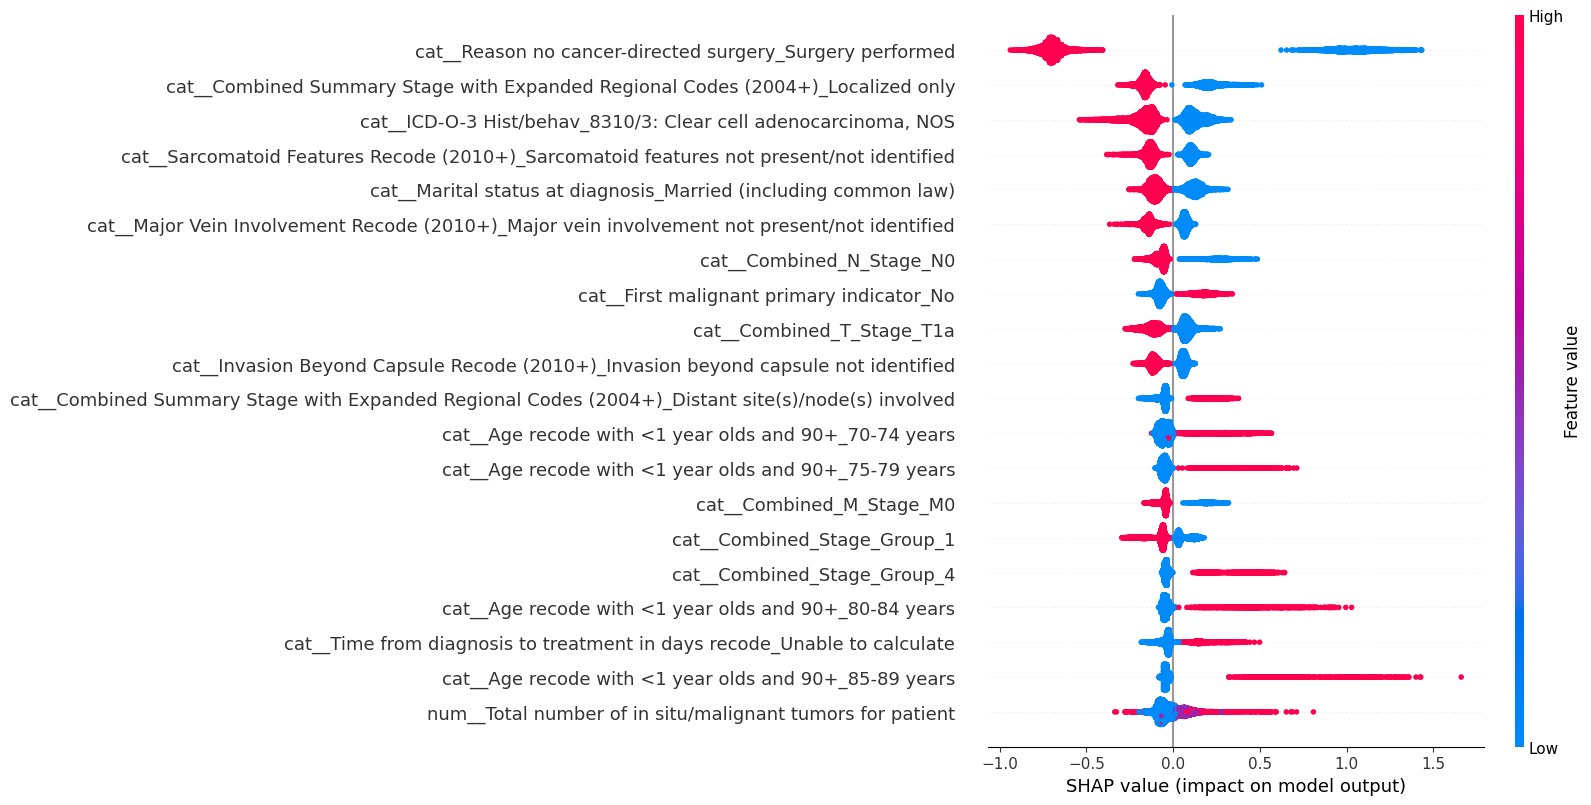

In [13]:
import shap
# =========================================================
# 10. SHAP computation on encoded data
# =========================================================

# Subsample for speed (you can increase/decrease n_bg)
# n_bg = min(2000, X.shape[0])
X_bg = X

preproc = pipe_final.named_steps["preprocess"]
xgb_step = pipe_final.named_steps["xgb"]

X_bg_proc = preproc.transform(X_bg)

# encoded feature names
try:
    feature_names_enc = preproc.get_feature_names_out()
except AttributeError:
    # fallback: generic names if get_feature_names_out is not available
    feature_names_enc = [f"feat_{i}" for i in range(X_bg_proc.shape[1])]

# TreeExplainer for XGB
explainer = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_bg_proc)

# Handle list output for binary classification if necessary
if isinstance(shap_values, list):
    shap_vals_2d = shap_values[1]
else:
    shap_vals_2d = shap_values

# =========================================================
# FIX: Convert Sparse Matrix to Dense for Plotting
# =========================================================
# Check if X_bg_proc is sparse (Scipy CSR matrix) and convert to dense numpy array
if hasattr(X_bg_proc, "toarray"):
    X_bg_proc_dense = X_bg_proc.toarray()
else:
    X_bg_proc_dense = X_bg_proc

# Create a Pandas DataFrame to keep values and names together
# This ensures SHAP sees the actual values (0, 1, etc.) for coloring
X_bg_proc_df = pd.DataFrame(X_bg_proc_dense, columns=feature_names_enc)

# =========================================================
# 12. SHAP summary plots (bar + beeswarm)
# =========================================================

# Beeswarm plot (Now with Red/Blue colors!)
plt.figure()
shap.summary_plot(
    shap_vals_2d,
    X_bg_proc_df,          # Pass the DENSE DataFrame here, not the sparse matrix
    feature_names=feature_names_enc,
    show=False,
)
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "xgb_shap_beeswarm.png"), dpi=300)
plt.show()